**What Algorithms to Apply?**
In this project, we will apply several machine learning algorithms to predict weather patterns based on a dataset that includes weather-related features. Specifically, we will implement:

Logistic Regression: A straightforward and interpretable model used for binary classification tasks, such as predicting whether it will rain or not. Logistic regression is a good starting point for understanding the basic relationship between features and the target variable, 'Rain'.

Random Forest: An ensemble method that combines multiple decision trees to improve classification accuracy by reducing overfitting. This model can handle complex and non-linear relationships between features and target, making it ideal for weather prediction tasks where feature interactions may not be linear.

Both models will be evaluated using metrics such as accuracy, F1-score, and ROC-AUC to compare their performance in predicting weather outcomes. We will also preprocess the data (standardization and handling missing values) to improve the model's accuracy.

# Model Evaluation and Hyperparameter Tuning
To evaluate how well our models perform, we will use these metrics:

Accuracy: This shows how many predictions were correct.
F1-score: This is useful when we care about both precision (correct positive predictions) and recall (finding all the actual positives), especially when one class (like "rain") is rarer than the other.
ROC-AUC: This helps us understand how well the model distinguishes between "rain" and "no rain" across different thresholds.
We will also use the confusion matrix to see how many correct and incorrect predictions the models made.

Additionally, we will use Grid Search to find the best settings for our models (called hyperparameters). This process helps us improve the models by testing different combinations of settings to get the best performance.

Finally, we will use cross-validation to ensure our models work well on new, unseen data and do not overfit to the training data.

# Import required Libraries:

In [1]:
import pandas as pd
import numpy as np # linear algebra
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_curve, precision_recall_curve


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
data = pd.read_csv("/kaggle/input/weather-forecast-dataset/weather_forecast_data.csv")


/kaggle/input/weather-forecast-dataset/weather_forecast_data.csv


In [3]:
print(data.info())
print("*"*50)
print(data.describe())
print("*"*50)
print(data.dtypes)
print("*"*50)
print(data.head())
print("*"*50)
print("number of missing data: ",data.isnull())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  2500 non-null   float64
 1   Humidity     2500 non-null   float64
 2   Wind_Speed   2500 non-null   float64
 3   Cloud_Cover  2500 non-null   float64
 4   Pressure     2500 non-null   float64
 5   Rain         2500 non-null   object 
dtypes: float64(5), object(1)
memory usage: 117.3+ KB
None
**************************************************
       Temperature     Humidity   Wind_Speed  Cloud_Cover     Pressure
count  2500.000000  2500.000000  2500.000000  2500.000000  2500.000000
mean     22.581725    64.347094     9.906255    49.658104  1014.312336
std       7.326996    19.954739     5.780316    29.123104    20.196433
min      10.001842    30.005071     0.009819     0.015038   980.014486
25%      16.359398    47.339815     4.761909    23.900016   996.938630
50%      22.536448    

# handling the missing data:

In [4]:
print(data.isnull().sum())
print("duplicated data: ",data.duplicated().sum())
improved_data = data.dropna()


Temperature    0
Humidity       0
Wind_Speed     0
Cloud_Cover    0
Pressure       0
Rain           0
dtype: int64
duplicated data:  0


# Identifying numerical and non-numerical columns in the dataset

In [5]:

numerical_data = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
non_numerical_data = data.select_dtypes(exclude=['int64', 'float64']).columns.tolist()

print("\nNumerical columns in the dataset:")
print(numerical_data)

print("\nNon-numerical columns in the dataset:")
print(non_numerical_data)


Numerical columns in the dataset:
['Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Pressure']

Non-numerical columns in the dataset:
['Rain']


**Model training**

In [6]:
X = data.drop('Rain', axis=1)
y = data['Rain']

Splitting data 80/20 ****

In [7]:
(X_train , X_test , y_train , y_test ) = train_test_split(X , y , test_size = 0.2 , random_state = 42)


In [8]:
# Drop rows with missing data from the training and testing sets
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]  # Ensure alignment after dropping rows in X_train
X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]  # Ensure alignment after dropping rows in X_test

In [9]:
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (2000, 5)
Testing features shape: (500, 5)
Training target shape: (2000,)
Testing target shape: (500,)


**Using of scalling**

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Initialize and train a Logistic Regression model**

In [11]:

log_reg_model = LogisticRegression()
log_reg_model.fit(X_train, y_train)

LogisticRegression()

# Make predictions

In [12]:
y_pred_log_reg = log_reg_model.predict(X_test)

# Calculate accuracy for Logistic Regression

In [13]:
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)

In [14]:

f1 = f1_score(y_test, y_pred_log_reg, pos_label='rain')
roc_auc = roc_auc_score(y_test, log_reg_model.predict_proba(X_test)[:, 1], multi_class='ovr')

# Display metrics
print(f"Logistic Regression F1-score: {f1:.4f}")
print(f"Logistic Regression ROC-AUC: {roc_auc:.4f}")

Logistic Regression F1-score: 0.6792
Logistic Regression ROC-AUC: 0.9583


In [15]:
print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")
print(f"Logistic Regression F1-score: {f1:.4f}")
print(f"Logistic Regression ROC-AUC: {roc_auc:.4f}")


Logistic Regression Accuracy: 0.9320
Logistic Regression F1-score: 0.6792
Logistic Regression ROC-AUC: 0.9583


# Display confusion matrix

In [16]:
cm = confusion_matrix(y_test, y_pred_log_reg)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[430  13]
 [ 21  36]]


# Display the confusion matrix visually

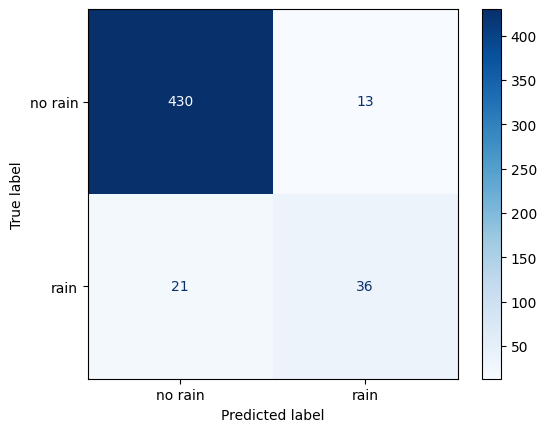

In [17]:

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Plot ROC Curve for Logistic Regression

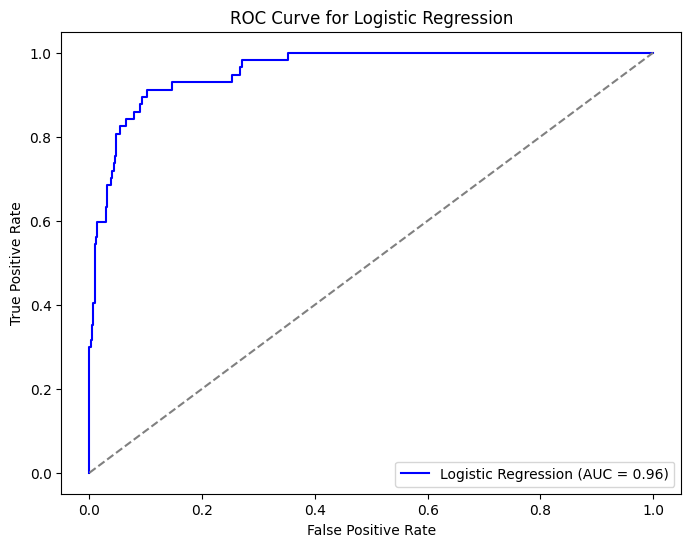

In [18]:
fpr, tpr, thresholds = roc_curve(y_test, log_reg_model.predict_proba(X_test)[:, 1], pos_label='rain')
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='Logistic Regression (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend(loc='lower right')
plt.show()


# Plot Precision-Recall Curve for Logistic Regression

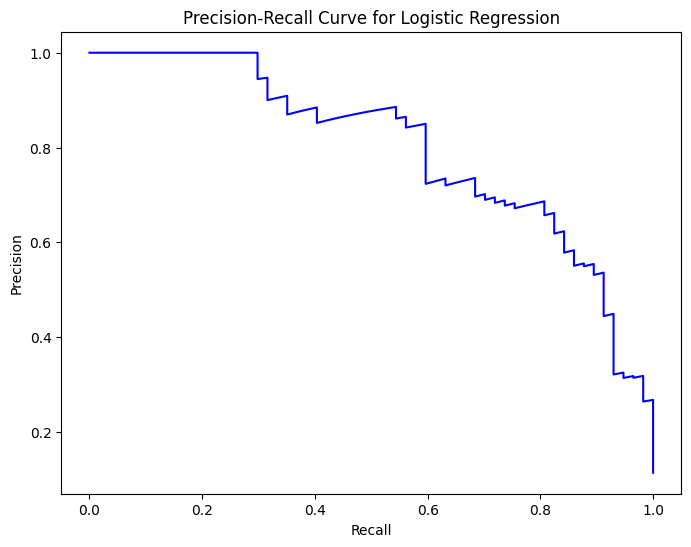

In [19]:
precision, recall, thresholds = precision_recall_curve(y_test, log_reg_model.predict_proba(X_test)[:, 1], pos_label='rain')
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Logistic Regression')
plt.show()

# random forest

In [20]:
# Initialize and train a Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [21]:
# Make predictions with the Random Forest model
y_pred_rf = rf_model.predict(X_test)

In [22]:
# Convert 'rain' to 1 and 'no rain' to 0 in y_test and y_pred_rf
y_test = y_test.map({'rain': 1, 'no rain': 0})
y_pred_rf = pd.Series(y_pred_rf).map({'rain': 1, 'no rain': 0})

# Calculate accuracy, F1-score, and ROC-AUC for Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, pos_label=1)  # 1 is for 'rain'
roc_auc_rf = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

# Display results
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest F1-score: {f1_rf:.4f}")
print(f"Random Forest ROC-AUC: {roc_auc_rf:.4f}")



Random Forest Accuracy: 0.9980
Random Forest F1-score: 0.9912
Random Forest ROC-AUC: 1.0000


In [23]:
# Display results for Random Forest
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest F1-score: {f1_rf:.4f}")
print(f"Random Forest ROC-AUC: {roc_auc_rf:.4f}")

Random Forest Accuracy: 0.9980
Random Forest F1-score: 0.9912
Random Forest ROC-AUC: 1.0000


In [24]:
# Display classification report and confusion matrix for Random Forest
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       443
           1       1.00      0.98      0.99        57

    accuracy                           1.00       500
   macro avg       1.00      0.99      1.00       500
weighted avg       1.00      1.00      1.00       500



In [25]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Random Forest Confusion Matrix:\n", cm_rf)

Random Forest Confusion Matrix:
 [[443   0]
 [  1  56]]


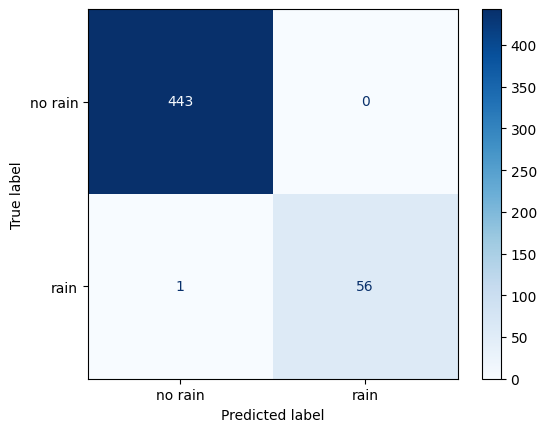

In [26]:
# Display the confusion matrix visually for Random Forest
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)
disp_rf.plot(cmap=plt.cm.Blues)
plt.show()

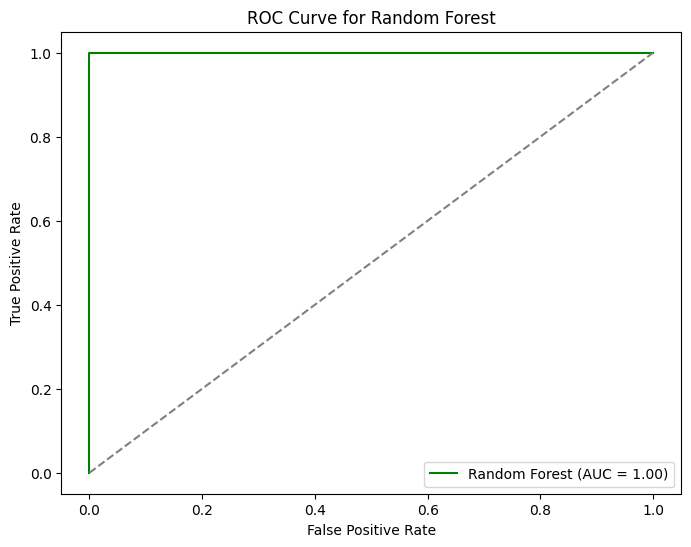

In [27]:
# Plot ROC Curve for Random Forest
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, rf_model.predict_proba(X_test)[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='green', label='Random Forest (AUC = {:.2f})'.format(roc_auc_rf))
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest')
plt.legend(loc='lower right')
plt.show()

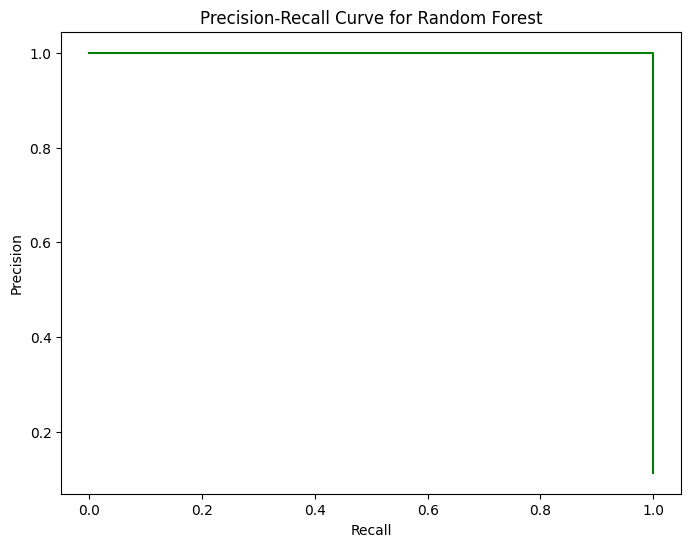

In [28]:
# Plot Precision-Recall Curve for Random Forest
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, rf_model.predict_proba(X_test)[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(recall_rf, precision_rf, color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Random Forest')
plt.show()

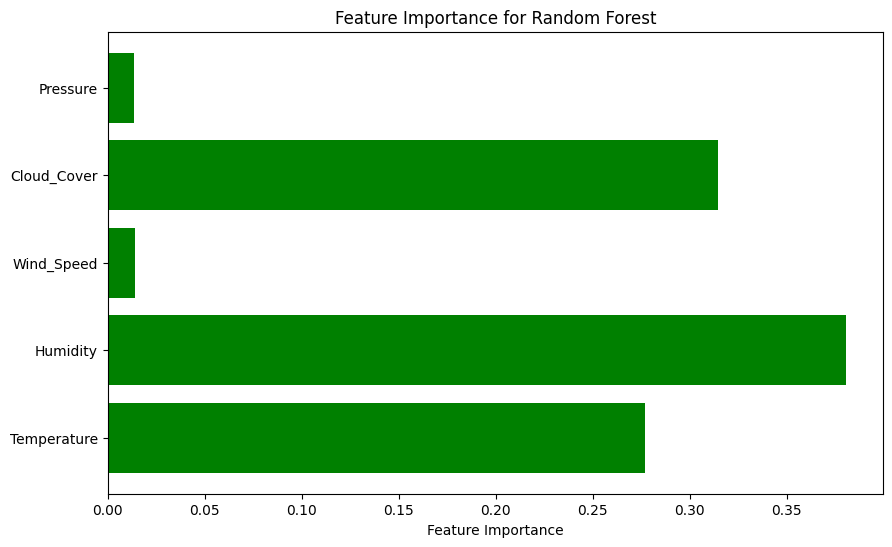

In [29]:
# Feature importance for Random Forest
feature_importances = rf_model.feature_importances_
features = X.columns

# Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(features, feature_importances, color='green')
plt.xlabel('Feature Importance')
plt.title('Feature Importance for Random Forest')
plt.show()

# Analysis of the Results

# Logistic Regression Metrics:
F1-score:

F1-score = 0.6792: This is a balanced measure of precision and recall. The F1-score being relatively moderate indicates that while the logistic regression model is performing well, there is still room for improvement in balancing precision and recall, especially in predicting rain occurrences.
ROC-AUC (Area Under the ROC Curve):

ROC-AUC = 0.9583: This is an excellent value, indicating that the model does a great job distinguishing between the classes ('rain' and 'no rain'). The ROC curve plots the true positive rate against the false positive rate, and an AUC value close to 1 indicates that the classifier is highly effective.
Accuracy:

Accuracy = 0.9320: This high accuracy means that the logistic regression model predicts correctly most of the time, but it is important to remember that accuracy alone can be misleading, especially with imbalanced datasets. A high accuracy does not necessarily mean that the model performs well across both classes (i.e., predicting both 'rain' and 'no rain').
Confusion Matrix:

The confusion matrix for Logistic Regression is:
lua
Copy code
[[430  13]
 [ 21  36]]
This means:
430 instances of 'no rain' were correctly predicted.

13 instances of 'no rain' were misclassified as 'rain'.

36 instances of 'rain' were correctly predicted.

21 instances of 'rain' were misclassified as 'no rain'.

The model tends to have more false negatives (predicting 'no rain' when it should have predicted 'rain'), which is a common challenge in weather prediction models.

ROC Curve:

The ROC curve for Logistic Regression shows a high True Positive Rate (sensitivity) with a low False Positive Rate, indicating that the classifier is highly sensitive in predicting rain.
The curve's area (AUC) of 0.9583 further confirms that the model is able to distinguish between the classes very well.
Precision-Recall Curve:

The Precision-Recall curve shows a clear trade-off between precision and recall. The curve’s shape suggests that recall could be improved with some sacrifices in precision, but overall, the logistic regression model provides a decent trade-off.
The precision decreases as recall increases because the model is making more 'rain' predictions, but some of them are incorrect.

# Random Forest Metrics:


F1-score = 0.9912: This is a very high F1-score, indicating that the Random Forest model is very good at balancing precision and recall, especially when predicting 'rain'. The model is highly optimized for both classes.
ROC-AUC:

ROC-AUC = 1.0000: This is a perfect AUC score, meaning the model has perfectly separated the classes ('rain' and 'no rain'). It classifies both classes without error.
Accuracy:

Accuracy = 0.9980: The Random Forest model has extremely high accuracy, which means it is very reliable in making correct predictions. However, this also raises the possibility of overfitting due to the perfect AUC, which requires further cross-validation to confirm generalization.
Confusion Matrix:

The confusion matrix for Random Forest is:
lua
Copy code
[[443   0]
 [  1  56]]
This means:
443 instances of 'no rain' were correctly predicted.
No 'no rain' instances were misclassified as 'rain'.
Only 1 instance of 'rain' was misclassified as 'no rain'.
56 instances of 'rain' were correctly predicted.
The model demonstrates almost perfect performance, with nearly no false positives or false negatives, suggesting very high precision and recall for the 'rain' category.
ROC Curve:

The ROC curve for Random Forest also shows a perfect separation between the classes with an AUC score of 1.0000. This means the model is highly effective at distinguishing between 'rain' and 'no rain'.
Precision-Recall Curve:

The Precision-Recall curve for Random Forest suggests an excellent trade-off, with very high precision and recall values across various thresholds. This is in line with the confusion matrix and overall high performance of the model.

# Conclusion:

The Logistic Regression model performs well with a good balance between precision and recall, but the Random Forest model significantly outperforms Logistic Regression, with near-perfect metrics across accuracy, F1-score, ROC-AUC, and confusion matrix.
The Random Forest model is likely to be the preferred choice for this dataset due to its superior performance in all aspects, including its ability to correctly classify both 'rain' and 'no rain' with very few misclassifications.
Logistic Regression, while performing decently, could be enhanced by further tuning or feature engineering to match the Random Forest’s performance, especially when dealing with imbalanced datasets where precision-recall trade-offs are critical.